# Data Preprocessing

Our current standard for our retinal images is 520x520 pixels retaining color as it is critical for proper diagnosis.

In [ ]:
# imports
import os
import zipfile
from pathlib import Path
import pandas as pd
import numpy as np
import gdown
import torch
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


Mounted at /content/drive


In [ ]:
random_seed = 67

In [ ]:
# Importing Datasets from Kaggle

# kaggle api token can be generated in your profile settings : https://www.kaggle.com/settings
# save kaggle api token in secrets

from google.colab import userdata
!export KAGGLE_API_TOKEN={userdata.get('KAGGLE_API_TOKEN')}

import kagglehub

# Download latest version of datasets
ds1 = kagglehub.dataset_download("linabennaa/eye-disease-image-dataset-mendeley")
ds2 = kagglehub.dataset_download("jeftaadriel/oia-odir-dataset")

Using Colab cache for faster access to the 'eye-disease-image-dataset-mendeley' dataset.
Using Colab cache for faster access to the 'oia-odir-dataset' dataset.


## Data Set 1

https://data.mendeley.com/datasets/s9bfhswzjb/1

https://www.kaggle.com/datasets/linabennaa/eye-disease-image-dataset-mendeley

- Coverage - Retinitis Pigmentosa, Retinal Detachment, Pterygium, Myopia, Macular Scar, Glaucoma, Disc Edema, Diabetic Retinopathy, Central Serous Chorioretinopathy
- Images - 16242 (# patients not confirmed)


In [ ]:
dataset_path = ds1 + '/Augmented Dataset'

image_paths = []
disease_labels = []

# Iterate through each disease folder
for disease_folder in os.listdir(dataset_path):
  disease_path = os.path.join(dataset_path, disease_folder)

  # Iterate through images in the disease folder
  for image_name in os.listdir(disease_path):

    image_full_path = os.path.join(disease_path, image_name)
    image_paths.append(image_full_path)
    disease_labels.append(disease_folder)

# Create a DataFrame
df_ds1 = pd.DataFrame({
  'image_path': image_paths,
  'eye_disease': disease_labels,
  'SOURCE':'ds1'
})

## Data Set 2

https://www.kaggle.com/datasets/jeftaadriel/oia-odir-dataset

- NOTE: Labels are in Chinese and includes images for both eyes
- Coverage - DIABETIC_RETINOPATHY, GLAUCOMA, CATARACT, AGE_RELATED_MACULAR_DEGENERATION, HYPERTENSION, MYOPIA, OTHER_DISEASES
- Images - 13000 (10k train, 2k on site test, 1k off site test) (# patients not confirmed)

Since the rest of our datasets are for singular eyes, we will be splitting this dataset into left and right eye and classifying based on the diagnosis for each eye.



In [ ]:
# Convert files to csv format
off_site_file = pd.read_excel(f"{ds2}/Off-site Test Set/Annotation/off-site test annotation (English).xlsx")
off_site_file.to_csv("off_site_test_annotation.csv", index=None, header=True)

on_site_file = pd.read_excel(f"{ds2}/On-site Test Set/Annotation/on-site test annotation (English).xlsx")
on_site_file.to_csv("on_site_test_annotation.csv", index=None, header=True)

training_file = pd.read_excel(f"{ds2}/Training Set/Annotation/training annotation (English).xlsx")
training_file.to_csv("training_annotation.csv", index=None, header=True)

# Base paths for images
base_path_off_site = ds2 + '/Off-site Test Set/Images/'
base_path_on_site = ds2 + '/On-site Test Set/Images/'
base_path_training = ds2 + '/Training Set/Images/'

# Add image paths to a DataFrame
def process_fundus_image_paths(df, base_path, left_col='Left-Fundus', right_col='Right-Fundus'):
    def add_image_path(filename, current_base_path):
        if pd.isna(filename):
            return filename
        return os.path.join(current_base_path, filename)

    df[left_col] = df[left_col].apply(lambda x: add_image_path(x, base_path))
    df[right_col] = df[right_col].apply(lambda x: add_image_path(x, base_path))
    return df

# Apply to each DataFrame
off_site_file = process_fundus_image_paths(off_site_file, base_path_off_site)
on_site_file = process_fundus_image_paths(on_site_file, base_path_on_site)
training_file = process_fundus_image_paths(training_file, base_path_training)

# Combine all DataFrames into one
df_ds2 = pd.concat([off_site_file, on_site_file, training_file], ignore_index=True)

# Remove specified columns
columns_to_remove = ['ID', 'Patient Age', 'Patient Sex', 'N', 'D', 'G', 'C', 'A', 'H', 'M', 'O']
df_ds2 = df_ds2.drop(columns=columns_to_remove)

# Convert Keywords into diagnosis for each eye
disease_mapping = {
    'normal': 'NORMAL',
    'diabetic retinopathy': 'DIABETIC_RETINOPATHY',
    'glaucoma': 'GLAUCOMA',
    'cataract': 'CATARACT',
    'macular degeneration': 'AGE_RELATED_MACULAR_DEGENERATION',
    'age-related macular degeneration': 'AGE_RELATED_MACULAR_DEGENERATION',
    'hypertensive retinopathy': 'HYPERTENSION',
    'myopia': 'MYOPIA',
}

df_left = df_ds2[['Left-Fundus', 'Left-Diagnostic Keywords']].copy()
df_right = df_ds2[['Right-Fundus', 'Right-Diagnostic Keywords']].copy()

df_left.columns = ['image_path', 'eye_disease']
df_right.columns = ['image_path', 'eye_disease']

# Get unique disease codes for column names
disease_codes = list(set(disease_mapping.values()))
disease_codes.append('OTHER_DISEASES')

def parse_diagnosis(df):
    # Initialize all disease columns with 0
    for disease in disease_codes:
        df[disease] = 0

    # Parse each row's diagnostic keywords
    for idx, keywords in df['eye_disease'].items():
        if pd.isna(keywords):
            continue

        # Convert to lowercase for matching
        keywords_lower = str(keywords).lower()

        disease_found = False

        # Check for each disease keyword in the mapping
        for keyword, disease_code in disease_mapping.items():
            if keyword in keywords_lower:
                df.at[idx, disease_code] = 1
                disease_found = True

        if not disease_found:
            df.at[idx, 'OTHER_DISEASES'] = 1

    df = df.drop('eye_disease', axis=1)

    return df

# Apply to both dataframes
df_left = parse_diagnosis(df_left)
df_right = parse_diagnosis(df_right)

# Combine to final dataset
df_ds2 = pd.concat([df_left, df_right], ignore_index=True)
df_ds2['SOURCE'] = 'ds2'


## Data Set 5

https://universe.roboflow.com/asmaa-qubdi/eye-diseases-7ng7m

- NOTE: The labels are in the png names…
- Coverage: Central Serous Chorioretinopathy, Diabetic Retinopathy, disc edema, glaucoma, macular scar, myopia, pterygium, retinal detachment, retinitis pigmentosa
- Images - 8425 images


In [ ]:
folder_link = "https://drive.google.com/drive/folders/1uoklEveAWV-yiaG9bWSv69jskgh_ySCs?usp=sharing"

In [ ]:

download_folder = "/content/gdrive_public"
os.makedirs(download_folder, exist_ok=True)

result = gdown.download_folder(
	url = folder_link,
	output = download_folder,
	quiet = False,
	use_cookies = False
)

# get file in result
zip_path = next(f for f in result if f.endswith(".zip"))

extract_to = os.path.splitext(zip_path)[0]
os.makedirs(extract_to, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zf:
  zf.extractall(extract_to)

# extracting all jpg files and putting them into one folder
import shutil

source = Path("/content/gdrive_public/Eye diseases.v1i.folder")
target = Path("/content/all_jpgs")
target.mkdir(parents=True, exist_ok=True)

jpg_files = list(source.rglob("*.jpg"))
print("Total images:", len(jpg_files))

for img_path in jpg_files:
  shutil.copy2(img_path, target / img_path.name)
# stored all of the jpg paths into target

# extracting classification
class_map = {
    "CSC": "Central Serous Chorioretinopathy",
    "DR": "Diabetic Retinopathy",
    "Disc-Edema": "Disc Edema",
    "Glaucoma": "Glaucoma",
    "Healthy": "Healthy",
    "Macular-Scar": "Macular Scar",
    "Myopia": "Myopia",
    "Pterygium": "Pterygium",
    "Retinal-Detachment": "Retinal Detachment",
    "Retinitis-Pigmentosa": "Retinitis Pigmentosa",
}

rows = []

for img_path in target.glob("*.jpg"):
  filename = img_path.name

  label = None
  for prefix, class_name in class_map.items():
    if filename.startswith(prefix):
      label = class_name
      break

  rows.append({
      "jpg_path": str(img_path),
      "classification": label
  })

df_ds5 = pd.DataFrame(rows)
df_ds5['SOURCE'] = 'ds5'

Retrieving folder contents


Processing file 1ejOBSpqz9rzkrcdKoG0DkJtbGFglN9UR Eye diseases.v1i.folder.zip


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From (original): https://drive.google.com/uc?id=1ejOBSpqz9rzkrcdKoG0DkJtbGFglN9UR
From (redirected): https://drive.google.com/uc?id=1ejOBSpqz9rzkrcdKoG0DkJtbGFglN9UR&confirm=t&uuid=3bcf2194-1052-40c4-867d-b43d67f496f7
To: /content/gdrive_public/Eye diseases.v1i.folder.zip
100%|██████████| 1.40G/1.40G [00:11<00:00, 124MB/s]
Download completed


Total images: 9160


## Data Set 6

https://github.com/openmedlab/Awesome-Medical-Dataset/blob/main/resources/Multi-LabelRetinalDiseases.md

- Coverage: Diabetic Retinopathy, media haze, optic disc cupping, tessellation, age-related macular degeneration, drusen, myopia, branch retinal vein occlusion, optic disc pallor, central retinal vein occlusion, choroidal neovascularization, retinitis, optic disc edema, laser scars, central serious retinopathy, hypertensive retinopathy, arteriosclerotic retinopathy, chorioretinitis, other diseases
- Images - 2208 images
- Resolution types - ranging from 520x520 to 3400x2800


In [ ]:
folder_link_6 = "https://drive.google.com/drive/folders/1NO7LASTtbYvfE6-2lKGp2rAJXiSISHee?usp=sharing"

download_folder_6 = "/content/gdrive_public"
os.makedirs(download_folder_6, exist_ok=True)

result_6 = gdown.download_folder(
	url = folder_link_6,
	output = download_folder_6,
	quiet = False,
	use_cookies = False
)

# save the files separately
images_zip, train_data_csv, val_data_csv = result_6

# unzip images
extract_dir = "/content/gdrive_public/images"
os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(images_zip, "r") as zip_ref:
  zip_ref.extractall(extract_dir)

# checking the images within extract_dir
all_images = list(Path(extract_dir).rglob("*"))

Retrieving folder contents


Processing file 11nJZrKAhepO_zZ5Ef15QADsIG39y4lzZ images.zip
Processing file 1xtDYMkkr20Xm4FDxV4FHIhrJ8-A-tImm train_data_8.csv
Processing file 1lYk5996KZ7DEHDirKlrbWHoTvkvt2ix- val_data_8.csv


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From (original): https://drive.google.com/uc?id=11nJZrKAhepO_zZ5Ef15QADsIG39y4lzZ
From (redirected): https://drive.google.com/uc?id=11nJZrKAhepO_zZ5Ef15QADsIG39y4lzZ&confirm=t&uuid=7a7c7030-1474-499b-98ec-6e1433fca76d
To: /content/gdrive_public/images.zip
100%|██████████| 5.44G/5.44G [00:48<00:00, 111MB/s]
Downloading...
From: https://drive.google.com/uc?id=1xtDYMkkr20Xm4FDxV4FHIhrJ8-A-tImm
To: /content/gdrive_public/train_data_8.csv
100%|██████████| 80.1k/80.1k [00:00<00:00, 59.7MB/s]
Downloading...
From: https://drive.google.com/uc?id=1lYk5996KZ7DEHDirKlrbWHoTvkvt2ix-
To: /content/gdrive_public/val_data_8.csv
100%|██████████| 20.1k/20.1k [00:00<00:00, 28.2MB/s]
Download completed


In [ ]:
# combine the train and validation set into one
temp_df = pd.concat([pd.read_csv(train_data_csv), pd.read_csv(val_data_csv)], ignore_index=True)

# adding image path to temp_df
image_path_map = {
    Path(p).stem: str(p)
    for p in all_images
}

df_ds6 = temp_df.copy()
df_ds6["image_path"] = df_ds6["ID"].astype(str).map(image_path_map)

# remove ID column from df_ds6
df_ds6.drop(columns=["ID"], inplace=True)
df_ds6['SOURCE'] = 'ds6'

## Combining the datsets into 1

In [ ]:
df_ds1_encoded = pd.get_dummies(df_ds1,columns = ['eye_disease'], prefix="", prefix_sep="", dtype=int)
df_ds1_encoded = df_ds1_encoded.rename(columns = {'Central Serous Chorioretinopathy_Color Fundus': 'Central Serous Retinopathy', 'Disc Edema': 'Optic Disc Edema','Healthy':'normal' })
df_ds1_encoded.columns = df_ds1_encoded.columns.str.upper()
df_ds1_encoded.columns = df_ds1_encoded.columns.str.replace(' ', '_')

In [ ]:
df_ds2_encoded = df_ds2.drop(columns=["OTHER_DISEASES"])
df_ds2_encoded.columns = df_ds2_encoded.columns.str.upper()

In [ ]:
df_ds5_encoded = pd.get_dummies(df_ds5, columns=['classification'], prefix="", prefix_sep="", dtype=int)
df_ds5_encoded = df_ds5_encoded.rename(columns={'Healthy': 'NORMAL', 'jpg_path': 'image_path'})
df_ds5_encoded.columns = df_ds5_encoded.columns.str.upper()
df_ds5_encoded.columns = df_ds5_encoded.columns.str.replace(' ', '_')

In [ ]:
df_ds6_encoded = df_ds6.rename(columns={'DR': 'DIABETIC_RETINOPATHY', 'MH':'MEDIA_HAZE', 'ODC': 'OPTIC_DISC_CUPPING', 'TSLN':'TESSELLATION', 'ARMD':'AGE_RELATED_MACULAR_DEGENERATION', 'DN':'DRUSEN', 'MYA':'MYOPIA', 'BRVO':'BRANCH_RETINAL_VEIN_OCCLUSION', 'ODP':'OPTIC_DISC_PALLOR', 'CRVO':'CENTRAL_RETINAL_VEIN_OCCLUSION', 'CNV':'CHOROIDAL NEOVASCULARIZATION', 'RS':'RETINITIS', 'ODE':'OPTIC_DISC_EDEMA', 'LS':'LASER_SCARS', 'CSR':'CENTRAL_SEROUS_RETINOPATHY', 'HTR':'HYPERTENSIVE_RETINOPATHY', 'ASR':'ARTERIOSCLEROTIC_RETINOPATHY', 'CRS':'CHORIORETINITIS'})
df_ds6_encoded = df_ds6_encoded.drop(columns=['OTHER'])
df_ds6_encoded.columns = df_ds6_encoded.columns.str.upper()
df_ds6_encoded.columns = df_ds6_encoded.columns.str.replace(' ', '_')

In [ ]:
df_full_encoded = pd.concat([df_ds1_encoded, df_ds2_encoded, df_ds5_encoded, df_ds6_encoded], ignore_index=True).fillna(0)
float_cols = df_full_encoded.select_dtypes(include="float").columns
df_full_encoded[float_cols] = df_full_encoded[float_cols].astype(int)

## Removing repeated eye diseases

In [ ]:
# Make a copy of the full encoded dataframe (assuming df_full_encoded exists)
df_merged = df_full_encoded.copy()

# Merge: CENTRAL_SEROUS_RETINOPATHY + CENTRAL_SEROUS_CHORIORETINOPATHY
df_merged['CENTRAL_SEROUS_RETINOPATHY'] = (
    df_merged['CENTRAL_SEROUS_RETINOPATHY'] | df_merged['CENTRAL_SEROUS_CHORIORETINOPATHY']
).astype(int)
df_merged = df_merged.drop(columns=['CENTRAL_SEROUS_CHORIORETINOPATHY'])

# Merge: OPTIC_DISC_EDEMA + DISC_EDEMA
df_merged['DISC_EDEMA'] = (
    df_merged['OPTIC_DISC_EDEMA'] | df_merged['DISC_EDEMA']
).astype(int)
df_merged = df_merged.drop(columns=['OPTIC_DISC_EDEMA'])

# Merge: HYPERTENSION + HYPERTENSIVE_RETINOPATHY
df_merged['HYPERTENSION'] = (
    df_merged['HYPERTENSION'] | df_merged['HYPERTENSIVE_RETINOPATHY']
).astype(int)
df_merged = df_merged.drop(columns=['HYPERTENSIVE_RETINOPATHY'])

# Merge: RETINITIS + CHORIORETINITIS
df_merged['RETINITIS'] = (
    df_merged['RETINITIS'] | df_merged['CHORIORETINITIS']
).astype(int)
df_merged = df_merged.drop(columns=['CHORIORETINITIS'])

# Update label_cols_merged after merging
label_cols_merged = [
    'CENTRAL_SEROUS_RETINOPATHY',
    'DIABETIC_RETINOPATHY',
    'GLAUCOMA',
    'NORMAL',
    'MACULAR_SCAR',
    'MYOPIA',
    'PTERYGIUM',
    'RETINAL_DETACHMENT',
    'RETINITIS_PIGMENTOSA',
    'HYPERTENSION',
    'CATARACT',
    'AGE_RELATED_MACULAR_DEGENERATION',
    'DISC_EDEMA',
    'MEDIA_HAZE',
    'OPTIC_DISC_CUPPING',
    'TESSELLATION',
    'DRUSEN',
    'BRANCH_RETINAL_VEIN_OCCLUSION',
    'OPTIC_DISC_PALLOR',
    'CENTRAL_RETINAL_VEIN_OCCLUSION',
    'CHOROIDAL_NEOVASCULARIZATION',
    'RETINITIS',
    'LASER_SCARS',
    'ARTERIOSCLEROTIC_RETINOPATHY',
]

'''
# Ensure merged class names are in the list
if 'CENTRAL_SEROUS_RETINOPATHY' not in label_cols_merged:
    label_cols_merged.append('CENTRAL_SEROUS_RETINOPATHY')
if 'OPTIC_DISC_EDEMA' not in label_cols_merged:
    label_cols_merged.append('OPTIC_DISC_EDEMA')
if 'HYPERTENSION' not in label_cols_merged:
    label_cols_merged.append('HYPERTENSION')
if 'RETINITIS' not in label_cols_merged:
    label_cols_merged.append('RETINITIS')'''

print("Merged label columns:", label_cols_merged)

Merged label columns: ['CENTRAL_SEROUS_RETINOPATHY', 'DIABETIC_RETINOPATHY', 'GLAUCOMA', 'NORMAL', 'MACULAR_SCAR', 'MYOPIA', 'PTERYGIUM', 'RETINAL_DETACHMENT', 'RETINITIS_PIGMENTOSA', 'HYPERTENSION', 'CATARACT', 'AGE_RELATED_MACULAR_DEGENERATION', 'DISC_EDEMA', 'MEDIA_HAZE', 'OPTIC_DISC_CUPPING', 'TESSELLATION', 'DRUSEN', 'BRANCH_RETINAL_VEIN_OCCLUSION', 'OPTIC_DISC_PALLOR', 'CENTRAL_RETINAL_VEIN_OCCLUSION', 'CHOROIDAL_NEOVASCULARIZATION', 'RETINITIS', 'LASER_SCARS', 'ARTERIOSCLEROTIC_RETINOPATHY']


## Checking class distribution and number of images per class

NORMAL                              8996
DIABETIC_RETINOPATHY                6121
GLAUCOMA                            4922
MYOPIA                              3943
MACULAR_SCAR                        2970
RETINITIS_PIGMENTOSA                1310
DISC_EDEMA                          1269
RETINAL_DETACHMENT                  1196
CENTRAL_SEROUS_RETINOPATHY           990
AGE_RELATED_MACULAR_DEGENERATION     561
CATARACT                             455
HYPERTENSION                         308
OPTIC_DISC_CUPPING                   263
MEDIA_HAZE                           169
PTERYGIUM                            162
DRUSEN                               162
TESSELLATION                         156
RETINITIS                             88
BRANCH_RETINAL_VEIN_OCCLUSION         79
OPTIC_DISC_PALLOR                     62
CHOROIDAL_NEOVASCULARIZATION          60
CENTRAL_RETINAL_VEIN_OCCLUSION        55
LASER_SCARS                           46
ARTERIOSCLEROTIC_RETINOPATHY          33
dtype: int64


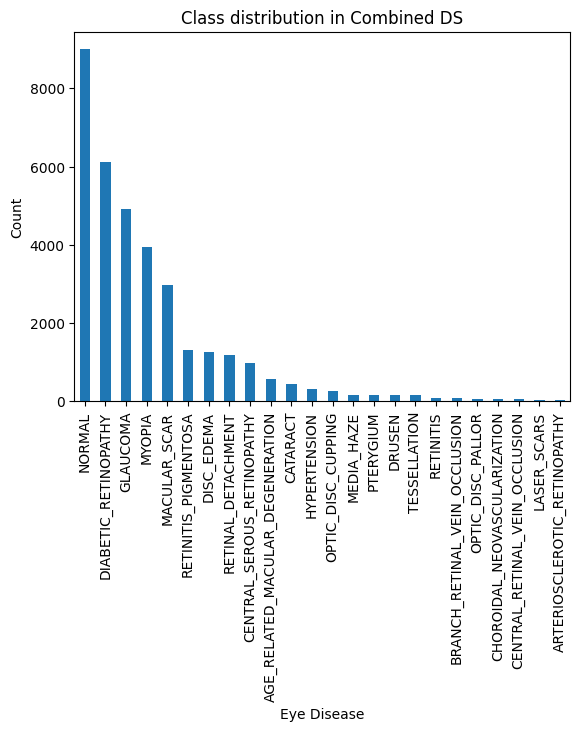

In [ ]:
class_counts_full = df_merged.drop(columns=['IMAGE_PATH', 'SOURCE']).sum()

print(class_counts_full.sort_values(ascending=False))

class_counts_full.sort_values(ascending=False).plot(
    kind="bar",
    title="Class distribution in Combined DS"
)
plt.xlabel("Eye Disease")
plt.ylabel("Count")
plt.show()

## Image Preprocessing

## Function for cropping out black border

In [ ]:
def crop_black_borders(image):
    # Convert PIL Image to NumPy array
    img_np = np.array(image)

    # Threshold for black pixels
    # Pixels with R, G, B values all below this threshold will be considered black
    BLACK_THRESHOLD = 10

    non_black_pixels = np.any(img_np > BLACK_THRESHOLD, axis=2)

    # Find rows and columns that contain non-black pixels
    rows = np.any(non_black_pixels, axis=1)
    cols = np.any(non_black_pixels, axis=0)

    # Get the min/max indices for cropping
    rmin, rmax = np.where(rows)[0][[0, -1]]
    cmin, cmax = np.where(cols)[0][[0, -1]]

    # Crop the NumPy array
    cropped_img_np = img_np[rmin:rmax+1, cmin:cmax+1]

    # Convert back to PIL Image
    return Image.fromarray(cropped_img_np)

## Ensuring images of same format

In [ ]:
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import v2

class FundusMultiLabelDataset(Dataset):
  def __init__(self, df:pd.DataFrame, label_cols, transform=None):
    self.labels_df = df
    self.transform = transform
    self.label_cols = label_cols

  def __len__(self):
    return len(self.labels_df)

  def __getitem__(self, idx):
    image_row = self.labels_df.iloc[idx]
    image_path = image_row['IMAGE_PATH']
    image = Image.open(image_path)

    if image.mode == "I;16":
      arr = np.array(image).astype("float32") / 65535.0
      arr = (arr * 255).astype("uint8")
      image = Image.fromarray(arr)

    image = image.convert("RGB")

    if self.transform:
      image = self.transform(image)

    labels = torch.tensor(image_row[self.label_cols].values.astype(np.float32), dtype=torch.float32)

    return {"image": image, "labels": labels}

## Transformation metrics

In [ ]:
# transformation metrics (same for train and validation)
train_transform = v2.Compose([
  v2.Lambda(crop_black_borders),
  v2.ToImage(),
  v2.Resize((224,224), antialias=True),
  v2.RandomHorizontalFlip(p=0.5),
  v2.RandomVerticalFlip(p=0.5),
  v2.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
  v2.RandomApply([v2.GaussianBlur(kernel_size=3, sigma=(0.1,1.0))], p=0.3),
  v2.ToDtype(torch.float32, scale=True),
  v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = v2.Compose([
  v2.Lambda(crop_black_borders),
  v2.ToImage(),
  v2.Resize((224,224), antialias=True),
  v2.ToDtype(torch.float32, scale=True),
  v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

## Additional augmentation for small classes (defined as <100 images)

In [ ]:
# Identify classes with < 100 images and augment them

# Count images per class (after merging)
class_counts = df_merged[label_cols_merged].sum()
low_freq_classes = class_counts[class_counts < 100].index.tolist()
print(f"Low-frequency classes (<100 images): {low_freq_classes}")

# Define augmentation functions with randomized Gaussian blur (sigma 0-0.1)
def augment_with_blur(image, seed_offset=0, flip_horizontal=False, flip_vertical=False):
    """
    Apply flips and a small randomized Gaussian blur.
    seed_offset ensures different random blur for each augmentation.
    """
    # Set seed for reproducibility based on seed_offset
    torch.manual_seed(67 + seed_offset)

    # Apply flips
    if flip_horizontal:
        image = v2.functional.horizontal_flip(image)
    if flip_vertical:
        image = v2.functional.vertical_flip(image)

    # Apply small randomized Gaussian blur (sigma between 0 and 0.1)
    # Note: GaussianBlur sigma expects at least 0.1, so we use a small range
    blur_sigma = (0.01, 0.1)  # Small blur amount
    blur = v2.GaussianBlur(kernel_size=3, sigma=blur_sigma)
    image = blur(image)

    return image

# Prepare list to collect augmented rows
augmented_rows = []

# For each low-frequency class, augment ALL images in that class
for cls in low_freq_classes:
    # Get indices where this class is 1
    cls_indices = df_merged[df_merged[cls] == 1].index.tolist()

    for idx in cls_indices:
        original_row = df_merged.loc[idx].to_dict()
        image_path = original_row['IMAGE_PATH']

        # Load image once
        img = Image.open(image_path)
        if img.mode == "I;16":
            arr = np.array(img).astype("float32") / 65535.0
            arr = (arr * 255).astype("uint8")
            img = Image.fromarray(arr)
        img = img.convert("RGB")

        # Convert to tensor for augmentation
        img_tensor = v2.ToImage()(img)

        # Create 3 augmented versions:
        # 1. Horizontal flip + small Gaussian blur
        img_aug1 = augment_with_blur(img_tensor, seed_offset=1,
                                      flip_horizontal=True, flip_vertical=False)
        # 2. Vertical flip + small Gaussian blur
        img_aug2 = augment_with_blur(img_tensor, seed_offset=2,
                                      flip_horizontal=False, flip_vertical=True)
        # 3. Horizontal + Vertical flip + small Gaussian blur
        img_aug3 = augment_with_blur(img_tensor, seed_offset=3,
                                      flip_horizontal=True, flip_vertical=True)

        # Save augmented images and add rows
        aug_configs = [
            ('hflip_blur', img_aug1),
            ('vflip_blur', img_aug2),
            ('hvflip_blur', img_aug3)
        ]

        for aug_name, aug_img in aug_configs:
            # Convert back to PIL for saving
            aug_pil = v2.ToPILImage()(aug_img)
            # Create new path
            base, ext = os.path.splitext(image_path)
            new_path = f"{base}_{aug_name}{ext}"
            aug_pil.save(new_path)

            # Create new row with same labels
            new_row = original_row.copy()
            new_row['IMAGE_PATH'] = new_path
            new_row['SOURCE'] = original_row['SOURCE'] + f"_aug_{aug_name}"
            augmented_rows.append(new_row)

# Convert augmented rows to DataFrame and concatenate
df_augmented = pd.DataFrame(augmented_rows)
df_final = pd.concat([df_merged, df_augmented], ignore_index=True)

print(f"Original size: {len(df_merged)}")
print(f"After augmentation: {len(df_final)}")
print(f"Expected size: {len(df_merged)} + {len(df_merged[df_merged[low_freq_classes].any(axis=1)]) * 3}")

Low-frequency classes (<100 images): ['BRANCH_RETINAL_VEIN_OCCLUSION', 'OPTIC_DISC_PALLOR', 'CENTRAL_RETINAL_VEIN_OCCLUSION', 'CHOROIDAL_NEOVASCULARIZATION', 'RETINITIS', 'LASER_SCARS', 'ARTERIOSCLEROTIC_RETINOPATHY']
Original size: 37610
After augmentation: 38879
Expected size: 37610 + 1200


### All classes

In [ ]:
LABEL_COLS = label_cols_merged

## Train/Val/Test Split

In [ ]:
!pip install iterative-stratification

## Initial multi-label stratification
This is for the train, validation, and test split (80/10/10). The validation and test set is reserved for the prediction model (second part of the fusion model).

In [ ]:
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit

def multilabel_train_val_test_split(df, label_cols, random_state, train_size=0.8, val_size=0.1, test_size=0.1):
  y = df[label_cols].values

  msss1 = MultilabelStratifiedShuffleSplit(
      n_splits=1,
      test_size=(1-train_size),
      random_state=random_state)

  train_idx, temp_idx = next(msss1.split(df,y))

  train_df = df.iloc[train_idx].reset_index(drop=True)
  temp_df = df.iloc[temp_idx].reset_index(drop=True)

  y_temp = temp_df[label_cols].values

  val_ratio = val_size / (val_size + test_size)

  msss2 = MultilabelStratifiedShuffleSplit(
      n_splits=1,
      test_size=(1-val_ratio),
      random_state=random_state)

  val_idx, test_idx = next(msss2.split(temp_df, y_temp))

  val_df = temp_df.iloc[val_idx].reset_index(drop=True)
  test_df = temp_df.iloc[test_idx].reset_index(drop=True)
  return train_df, val_df, test_df

In [ ]:
# conduct the split
train_df, val_df, test_df = multilabel_train_val_test_split(
    df_final,
    LABEL_COLS,
    random_state=random_seed)

In [ ]:
# obtain the dataset (transformed data)
train_dataset = FundusMultiLabelDataset(
    df=train_df,
    label_cols=LABEL_COLS,
    transform=train_transform
)

val_dataset = FundusMultiLabelDataset(
    df=val_df,
    label_cols=LABEL_COLS,
    transform=val_transform
)

test_dataset = FundusMultiLabelDataset(
    df=test_df,
    label_cols=LABEL_COLS,
    transform=val_transform
)

In [ ]:
# DataLoader for the CNNs
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=4,
    pin_memory=True
    )

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

## Multi-label stratification for the CNNs
This is the train/validation split for the CNNs specifically (80/20). It splits the original training dataset.

In [ ]:
# Multilabel stratified split (80/20) for training/validation (for the CNNs)
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit

def multilabel_train_val_split(df, label_cols, random_state=67, train_size=0.8):
    y = df[label_cols].values

    msss = MultilabelStratifiedShuffleSplit(
        n_splits=1,
        test_size=(1 - train_size),
        random_state=random_state
    )

    train_idx, val_idx = next(msss.split(df, y))

    train_df = df.iloc[train_idx].reset_index(drop=True)
    val_df = df.iloc[val_idx].reset_index(drop=True)

    return train_df, val_df

# Perform the split
train_df_final, val_df_final = multilabel_train_val_split(
    train_df,
    label_cols_merged,
    random_state=67,
    train_size=0.8
)

print(f"Train size: {len(train_df_final)}")
print(f"Validation size: {len(val_df_final)}")

# Create Datasets and DataLoaders (for the CNNs)
train_dataset_final = FundusMultiLabelDataset(
    df=train_df_final,
    label_cols=LABEL_COLS,
    transform=train_transform
)

val_dataset_final = FundusMultiLabelDataset(
    df=val_df_final,
    label_cols=LABEL_COLS,
    transform=val_transform
)

train_loader_final = DataLoader(
    train_dataset_final,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

val_loader_final = DataLoader(
    val_dataset_final,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

Train size: 24882
Validation size: 6221


# Feature Extraction

## Importing in models

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Feature extraction function

In [ ]:
# feature extraction function
import numpy as np
from tqdm.auto import tqdm
import torch

@torch.no_grad()
def extract_features(model, loader, device):
    model.eval()
    model.return_features = True

    all_features = []
    all_labels = []

    for batch in tqdm(loader, desc="Extracting features"):
        images = batch["image"].to(device)          # [B, 3, 224, 224]
        labels = batch["labels"]                    # [B, num_classes]

        logits, features = model(images)            # features: [B, 1024]

        all_features.append(features.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

    all_features = np.concatenate(all_features, axis=0)   # [N, 1024]
    all_labels = np.concatenate(all_labels, axis=0)       # [N, num_classes]

    return all_features, all_labels

### ShuffleNetV2

In [ ]:
# defining the model class before loading
import torch
import torch.nn as nn
from torchvision import models
from torchvision.models import ShuffleNet_V2_X1_0_Weights

class ShuffleNetV2MultiLabel(nn.Module):
    def __init__(self, num_classes, pretrained=True, dropout=0.2, return_features=False):
        super().__init__()
        self.return_features = return_features

        weights = ShuffleNet_V2_X1_0_Weights.DEFAULT if pretrained else None
        backbone = models.shufflenet_v2_x1_0(weights=weights)

        in_features = backbone.fc.in_features
        backbone.fc = nn.Identity()

        self.backbone = backbone
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(in_features, num_classes)

    def forward(self, x):
        features = self.backbone(x)   # [B, 1024]
        logits = self.classifier(self.dropout(features))

        if self.return_features:
            return logits, features
        return logits

In [ ]:
# loading the full model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_path_shufflenet = "/content/drive/MyDrive/Deep Learning Project/Emily Models/shufflenetv2_model_feature.pth"
shufflenet_model = torch.load(model_path_shufflenet, map_location=device, weights_only=False)
shufflenet_model.to(device)
shufflenet_model.eval()

In [ ]:
# turn on feature return
shufflenet_model.return_features = True

In [ ]:
# loading the features
shufflenet_train_features, shufflenet_train_labels = extract_features(
    shufflenet_model,
    train_loader_final,
    device
)

shufflenet_cnnval_features, shufflenet_cnnval_labels = extract_features(
    shufflenet_model,
    val_loader_final,
    device
)

shufflenet_fusionval_features, shufflenet_fusionval_labels = extract_features(
    shufflenet_model,
    val_loader,
    device
)

shufflenet_test_features, shufflenet_test_labels = extract_features(
    shufflenet_model,
    test_loader,
    device
)

print("ShuffleNet train features:", shufflenet_train_features.shape)
print("ShuffleNet CNN-val features:", shufflenet_cnnval_features.shape)
print("ShuffleNet fusion-val features:", shufflenet_fusionval_features.shape)
print("ShuffleNet test features:", shufflenet_test_features.shape)

### EfficientNet

In [ ]:
SAVED_PATH_EFFICIENTNET = "/content/drive/MyDrive/Deep Learning Project/Joe Models/model_checkpoints/best.pth"

In [ ]:
from torchvision.models import efficientnet_b0

class EfficientNetMultiLabel(nn.Module):
  def __init__(self, num_classes, pretrained=True, dropout=0.2):
    super().__init__()

    weights = models.EfficientNet_B0_Weights.DEFAULT if pretrained else None
    backbone = efficientnet_b0(weights=weights)
    feature_dim = backbone.classifier[1].in_features

    self.features = backbone.features
    self.avgpool = backbone.avgpool
    self.feature_dim = feature_dim
    self.classifier = nn.Sequential(
        nn.Dropout(p=dropout),
        nn.Linear(feature_dim, num_classes)
    )

  def forward(self, x):
    x = self.features(x)
    x = self.avgpool(x)
    features = torch.flatten(x, 1)
    logits = self.classifier(features)
    return logits, features


In [ ]:
efficientnet_model = EfficientNetMultiLabel(num_classes=24).to(device)

In [ ]:
# loading the features
efficientnet_train_features, efficientnet_train_labels = extract_features(
    efficientnet_model,
    train_loader_final,
    device
)

efficientnet_cnnval_features, efficientnet_cnnval_labels = extract_features(
    efficientnet_model,
    val_loader_final,
    device
)

efficientnet_fusionval_features, efficientnet_fusionval_labels = extract_features(
    efficientnet_model,
    val_loader,
    device
)

efficientnet_test_features, efficientnet_test_labels = extract_features(
    efficientnet_model,
    test_loader,
    device
)

print("EfficientNet train features:", efficientnet_train_features.shape)
print("EfficientNet CNN-val features:", efficientnet_cnnval_features.shape)
print("EfficientNet fusion-val features:", efficientnet_fusionval_features.shape)
print("EfficientNet test features:", efficientnet_test_features.shape)

### ResNet

In [ ]:
from torchvision.models import ResNet50_Weights
import torch
import torch.nn as nn
from torchvision import models


class ResNetBackbone(nn.Module):
    def __init__(self, resnet_version='resnet50', pretrained=True):
        super(ResNetBackbone, self).__init__()

        from torchvision.models import resnet50, ResNet50_Weights
        weights = ResNet50_Weights.IMAGENET1K_V1 if pretrained else None
        self.resnet = resnet50(weights=weights)
        self.feature_dim = 2048

        self.resnet = nn.Sequential(*list(self.resnet.children())[:-1])

    def forward(self, x):
        features = self.resnet(x)
        return features.view(features.size(0), -1)

class ResNetMultiLabelClassifier(nn.Module):
    def __init__(self, num_classes=24, dropout=0.2, return_features=False):
        super(ResNetMultiLabelClassifier, self).__init__()
        self.return_features = return_features

        # Clean backbone (raw features only)
        self.backbone = ResNetBackbone(resnet_version='resnet50', pretrained=True)
        feature_dim = self.backbone.feature_dim  # 2048 for ResNet50

        # Simple classifier
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(feature_dim, num_classes)
        )

    def forward(self, x):
        features = self.backbone(x)  # [B, 2048]
        logits = self.classifier(features)

        if self.return_features:
            return logits, features
        return logits

In [ ]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


resnet_model = ResNetMultiLabelClassifier(num_classes=24, dropout=0.2, return_features=False)


resnet_model_path = "/content/drive/MyDrive/Deep Learning Project/Si Yue Models/checkpoint_epoch_15.pth"
resnet_model_checkpoint = torch.load(resnet_model_path, map_location=device, weights_only=False)
resnet_model.load_state_dict(resnet_model_checkpoint['model_state_dict'])
resnet_model.to(device)

resnet_model.eval()

In [ ]:
# loading the features

resnet_model.return_features = True

# Extract all needed features
resnet_train_features, resnet_train_labels = extract_features(
    resnet_model, train_loader_final, device
)

resnet_cnnval_features, resnet_cnnval_labels = extract_features(
    resnet_model, val_loader_final, device
)

resnet_fusionval_features, resnet_fusionval_labels = extract_features(
    resnet_model, val_loader, device
)

resnet_test_features, resnet_test_labels = extract_features(
    resnet_model, test_loader, device
)

print("ResNet fusion-val features:", resnet_fusionval_features.shape)
print("ResNet test features:", resnet_test_features.shape)

In [ ]:
import numpy as np

# CNN-train split alignment
assert np.array_equal(shufflenet_train_labels, efficientnet_train_labels)
assert np.array_equal(shufflenet_train_labels, resnet_train_labels)

# CNN-validation split alignment
assert np.array_equal(shufflenet_cnnval_labels, efficientnet_cnnval_labels)
assert np.array_equal(shufflenet_cnnval_labels, resnet_cnnval_labels)

# Fusion-validation split alignment
assert np.array_equal(shufflenet_fusionval_labels, efficientnet_fusionval_labels)
assert np.array_equal(shufflenet_fusionval_labels, resnet_fusionval_labels)

# Test split alignment
assert np.array_equal(shufflenet_test_labels, efficientnet_test_labels)
assert np.array_equal(shufflenet_test_labels, resnet_test_labels)

print("All feature labels are aligned.")

### Saving the extracted features

In [ ]:
import numpy as np
import os

save_dir = "extracted_features"
os.makedirs(save_dir, exist_ok=True)

In [ ]:
ShuffleNet
np.savez_compressed(
    os.path.join(save_dir, "shufflenet_features.npz"),
    train_features=shufflenet_train_features,
    train_labels=shufflenet_train_labels,
    cnnval_features=shufflenet_cnnval_features,
    cnnval_labels=shufflenet_cnnval_labels,
    fusionval_features=shufflenet_fusionval_features,
    fusionval_labels=shufflenet_fusionval_labels,
    test_features=shufflenet_test_features,
    test_labels=shufflenet_test_labels
)

# EfficientNet
np.savez_compressed(
    os.path.join(save_dir, "efficientnet_features.npz"),
    train_features=efficientnet_train_features,
    train_labels=efficientnet_train_labels,
    cnnval_features=efficientnet_cnnval_features,
    cnnval_labels=efficientnet_cnnval_labels,
    fusionval_features=efficientnet_fusionval_features,
    fusionval_labels=efficientnet_fusionval_labels,
    test_features=efficientnet_test_features,
    test_labels=efficientnet_test_labels
)

# ResNet
np.savez_compressed(
    os.path.join(save_dir, "resnet_features.npz"),
    train_features=resnet_train_features,
    train_labels=resnet_train_labels,
    cnnval_features=resnet_cnnval_features,
    cnnval_labels=resnet_cnnval_labels,
    fusionval_features=resnet_fusionval_features,
    fusionval_labels=resnet_fusionval_labels,
    test_features=resnet_test_features,
    test_labels=resnet_test_labels
)
from google.colab import files

files.download(os.path.join(save_dir, "resnet_features.npz"))

print("Saved ShuffleNet and EfficientNet extracted features.")

# Transformer

Process: <br>
1. 3 CNN feature vectors
2. projection to common size
3. transformer encoder
4. attention scoring

## Define fusion dataset

In [ ]:
import numpy as np
import os
import torch
from torch.utils.data import Dataset, DataLoader

features_dir = "/content/drive/MyDrive/Deep Learning Project/Extracted Features/"

# Load ShuffleNet features
shufflenet_data = np.load(os.path.join(features_dir, "shufflenet_features.npz"))
shufflenet_train_features = shufflenet_data['train_features']
shufflenet_train_labels = shufflenet_data['train_labels']
shufflenet_cnnval_features = shufflenet_data['cnnval_features']
shufflenet_cnnval_labels = shufflenet_data['cnnval_labels']
shufflenet_fusionval_features = shufflenet_data['fusionval_features']
shufflenet_fusionval_labels = shufflenet_data['fusionval_labels']
shufflenet_test_features = shufflenet_data['test_features']
shufflenet_test_labels = shufflenet_data['test_labels']

# Load EfficientNet features
efficientnet_data = np.load(os.path.join(features_dir, "efficientnet_features.npz"))
efficientnet_train_features = efficientnet_data['train_features']
efficientnet_train_labels = efficientnet_data['train_labels']
efficientnet_cnnval_features = efficientnet_data['cnnval_features']
efficientnet_cnnval_labels = efficientnet_data['cnnval_labels']
efficientnet_fusionval_features = efficientnet_data['fusionval_features']
efficientnet_fusionval_labels = efficientnet_data['fusionval_labels']
efficientnet_test_features = efficientnet_data['test_features']
efficientnet_test_labels = efficientnet_data['test_labels']

# Load ResNet features
resnet_data = np.load(os.path.join(features_dir, "resnet_features.npz"))
resnet_train_features = resnet_data['train_features']
resnet_train_labels = resnet_data['train_labels']
resnet_cnnval_features = resnet_data['cnnval_features']
resnet_cnnval_labels = resnet_data['cnnval_labels']
resnet_fusionval_features = resnet_data['fusionval_features']
resnet_fusionval_labels = resnet_data['fusionval_labels']
resnet_test_features = resnet_data['test_features']
resnet_test_labels = resnet_data['test_labels']

print("All features loaded successfully!")
print(f"ShuffleNet train features: {shufflenet_train_features.shape}")
print(f"EfficientNet train features: {efficientnet_train_features.shape}")
print(f"ResNet train features: {resnet_train_features.shape}")

All features loaded successfully!
ShuffleNet train features: (24882, 1024)
EfficientNet train features: (24882, 1280)
ResNet train features: (24882, 2048)


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader

class FusionFeatureDataset(Dataset):
    def __init__(self, shuffle_features, eff_features, res_features, labels):
        self.shuffle_features = torch.tensor(shuffle_features, dtype=torch.float32)
        self.eff_features = torch.tensor(eff_features, dtype=torch.float32)
        self.res_features = torch.tensor(res_features, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "shuffle_features": self.shuffle_features[idx],
            "eff_features": self.eff_features[idx],
            "res_features": self.res_features[idx],
            "labels": self.labels[idx]
        }

In [ ]:
# combine CNN train split + CNN validation split for transformer training

shufflenet_fusiontrain_features = np.concatenate(
    [shufflenet_train_features, shufflenet_cnnval_features],
    axis=0
)

efficientnet_fusiontrain_features = np.concatenate(
    [efficientnet_train_features, efficientnet_cnnval_features],
    axis=0
)

resnet_fusiontrain_features = np.concatenate(
    [resnet_train_features, resnet_cnnval_features],
    axis=0
)

fusiontrain_labels = np.concatenate(
    [shufflenet_train_labels, shufflenet_cnnval_labels],
    axis=0
)

print("Fusion train ShuffleNet:", shufflenet_fusiontrain_features.shape)
print("Fusion train EfficientNet:", efficientnet_fusiontrain_features.shape)
print("Fusion train ResNet:", resnet_fusiontrain_features.shape)
print("Fusion train labels:", fusiontrain_labels.shape)

Fusion train ShuffleNet: (31103, 1024)
Fusion train EfficientNet: (31103, 1280)
Fusion train ResNet: (31103, 2048)
Fusion train labels: (31103, 24)


In [ ]:
# defining fusion features dataset -> taking in input from all three CNNs
train_fusion_dataset = FusionFeatureDataset(
    shuffle_features=shufflenet_fusiontrain_features,
    eff_features=efficientnet_fusiontrain_features,
    res_features=resnet_fusiontrain_features,
    labels=fusiontrain_labels
)

val_fusion_dataset = FusionFeatureDataset(
    shuffle_features=shufflenet_fusionval_features,
    eff_features=efficientnet_fusionval_features,
    res_features=resnet_fusionval_features,
    labels=shufflenet_fusionval_labels
)

# test set
test_fusion_dataset = FusionFeatureDataset(
    shuffle_features=shufflenet_test_features,
    eff_features=efficientnet_test_features,
    res_features=resnet_test_features,
    labels=shufflenet_test_labels
)

In [ ]:
# fusion data loader (to pass into transformer)
train_fusion_loader = DataLoader(
    train_fusion_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0,
    drop_last=True
)

val_fusion_loader = DataLoader(
    val_fusion_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0
)

test_fusion_loader = DataLoader(
    test_fusion_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0
)

## Define and apply transformer

In [ ]:
import torch
import torch.nn as nn

class TransformerAttentionFusion(nn.Module):
    def __init__(
        self,
        dim_shuffle=1024,
        dim_eff=1280,
        dim_res=2048,
        embed_dim=512,
        num_heads=8,
        num_transformer_layers=1,
        transformer_dropout=0.1 # define input drop out at 0.1
    ):
        super().__init__()

        # Project each CNN feature vector to common embedding size
        self.proj_shuffle = nn.Linear(dim_shuffle, embed_dim)
        self.proj_eff = nn.Linear(dim_eff, embed_dim)
        self.proj_res = nn.Linear(dim_res, embed_dim)

        # Normalize projected embeddings
        self.norm_shuffle = nn.LayerNorm(embed_dim)
        self.norm_eff = nn.LayerNorm(embed_dim)
        self.norm_res = nn.LayerNorm(embed_dim)

        # Learnable token identity embeddings
        self.token_type_embed = nn.Parameter(torch.randn(1, 3, embed_dim))

        # Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=embed_dim * 2,
            dropout=transformer_dropout,
            activation="relu", # relu activation function
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_transformer_layers
        )

        # Attention scoring MLP: outputs 1 score per token
        self.attn_mlp = nn.Sequential(
            nn.Linear(embed_dim, 128), # input layer
            nn.ReLU(), # relu activation function
            nn.Linear(128, 1) # output layer
        )

    def forward(self, f_shuffle, f_eff, f_res):
        """
        f_shuffle: [B, 1024]
        f_eff:     [B, 1280]
        f_res:     [B, 2048]
        """

        # 1. Project to common embedding size since each of the CNNs differ in feature size
        z_shuffle = self.norm_shuffle(self.proj_shuffle(f_shuffle))   # [B, 512]
        z_eff = self.norm_eff(self.proj_eff(f_eff))                   # [B, 512]
        z_res = self.norm_res(self.proj_res(f_res))                   # [B, 512]

        # 2. Stack as 3 tokens (to pass into transformer since transformer input is tokens)
        tokens = torch.stack([z_shuffle, z_eff, z_res], dim=1)        # [B, 3, 512]
        # each CNN as 1 token

        # 3. Add token identity embeddings
        tokens = tokens + self.token_type_embed                       # [B, 3, 512]

        # 4. Transformer encoder
        tokens = self.transformer(tokens)                             # [B, 3, 512]

        # 5. Attention scores
        scores = self.attn_mlp(tokens).squeeze(-1)                    # [B, 3]

        # 6. Softmax weights
        weights = torch.softmax(scores, dim=1)                        # [B, 3]

        # 7. Weighted sum fusion
        fused = torch.sum(tokens * weights.unsqueeze(-1), dim=1)      # [B, 512]
        # attention scores derived from transformer
        # use attention scores to weigh features from CNNs

        return fused, weights, tokens, scores

In [ ]:
# initialize transformer for fusion model
fusion_model = TransformerAttentionFusion(
    dim_shuffle=1024,
    dim_eff=1280,
    dim_res=2048,
    embed_dim=512,
    num_heads=8,
    num_transformer_layers=1,
    transformer_dropout=0.1 # define drop out at 0.1 before transformer
).to(device)

Application of transformer combined with prediction block. It is the start of the application of the prediction block.

# **Prediction Block**

## Defining the prediction block architecture

In [ ]:
import torch
import torch.nn as nn

class PredictionBlock(nn.Module):
    def __init__(self, input_dim=512, hidden_dim=256, num_classes=24):
        super().__init__()

        self.net = nn.Sequential(
            nn.Dropout(0.1), # input dropout
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.LayerNorm(hidden_dim), # LayerNorm over BatchNorm1d to avoid small batches issues
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, x):
        # x: [B, 512]
        return self.net(x)   # logits: [B, 24]
        # 24 classes

## Application (training) of transformer and prediction block

In [ ]:
# importing necessary libraries
import torch.nn as nn
from torch.optim import AdamW
from sklearn.metrics import f1_score, accuracy_score
import numpy as np

# applying the transformer and prediction block
# initializing the prediction block
prediction_block = PredictionBlock(
    input_dim=512,
    hidden_dim=256,
    num_classes=24
).to(device)

#fusion_model.eval()
#prediction_block.eval()

# loss function
# BCE has sigmoid inside -> multilabel classification
criterion = nn.BCEWithLogitsLoss()

# optimizer training both transformer and prediction block
optimizer = torch.optim.AdamW(
    list(fusion_model.parameters()) + list(prediction_block.parameters()),
    lr = 1e-4,
    weight_decay = 1e-4
)

num_epochs = 15
threshold = 0.5 # setting 0.5 threshold

'''
for batch in train_fusion_loader:
    f_shuffle = batch["shuffle_features"].to(device)   # [B, 1024]
    f_eff = batch["eff_features"].to(device)           # [B, 1280]
    f_res = batch["res_features"].to(device)           # [B, 2048]

    with torch.no_grad():
      # apply transformer to the extracted features from the CNNs
      fused, weights, tokens, scores = fusion_model(f_shuffle, f_eff, f_res)  # fused: [B, 512]
      logits = prediction_block(fused)                                        # [B, 24]
      probs = torch.sigmoid(logits)                                           # [B, 24]

    print("Fused shape:", fused.shape)
    print("Logits shape:", logits.shape)
    print("Probabilities shape:", probs.shape)
    break'''

'\nfor batch in train_fusion_loader:\n    f_shuffle = batch["shuffle_features"].to(device)   # [B, 1024]\n    f_eff = batch["eff_features"].to(device)           # [B, 1280]\n    f_res = batch["res_features"].to(device)           # [B, 2048]\n\n    with torch.no_grad():\n      # apply transformer to the extracted features from the CNNs\n      fused, weights, tokens, scores = fusion_model(f_shuffle, f_eff, f_res)  # fused: [B, 512]\n      logits = prediction_block(fused)                                        # [B, 24]\n      probs = torch.sigmoid(logits)                                           # [B, 24]\n\n    print("Fused shape:", fused.shape)\n    print("Logits shape:", logits.shape)\n    print("Probabilities shape:", probs.shape)\n    break'

In [ ]:
import torch.nn as nn
from torch.optim import AdamW
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, hamming_loss
import numpy as np

# training function
def train_one_epoch(fusion_model, prediction_block, train_loader, optimizer, criterion, device):
    fusion_model.train()
    prediction_block.train()

    total_loss = 0.0

    for batch in train_loader:
        f_shuffle = batch["shuffle_features"].to(device)
        f_eff = batch["eff_features"].to(device)
        f_res = batch["res_features"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()

        fused, weights, tokens, scores = fusion_model(
            f_shuffle,
            f_eff,
            f_res
        )

        logits = prediction_block(fused)
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(train_loader)

# validation function
def evaluate_multilabel_model(
    fusion_model,
    prediction_block,
    data_loader,
    criterion,
    device,
    threshold=0.5
):
    fusion_model.eval()
    prediction_block.eval()

    total_loss = 0.0
    all_labels = []
    all_preds = []
    all_probs = []

    with torch.no_grad():
        for batch in data_loader:
            f_shuffle = batch["shuffle_features"].to(device)
            f_eff = batch["eff_features"].to(device)
            f_res = batch["res_features"].to(device)
            labels = batch["labels"].to(device)

            fused, weights, tokens, scores = fusion_model(
                f_shuffle,
                f_eff,
                f_res
            )

            logits = prediction_block(fused)
            loss = criterion(logits, labels)

            probs = torch.sigmoid(logits)
            preds = (probs >= threshold).float()

            total_loss += loss.item()

            all_labels.append(labels.cpu().numpy())
            all_probs.append(probs.cpu().numpy())
            all_preds.append(preds.cpu().numpy())

    all_labels = np.vstack(all_labels)
    all_probs = np.vstack(all_probs)
    all_preds = np.vstack(all_preds)

    metrics = {
        "loss": total_loss / len(data_loader),
        "micro_f1": f1_score(all_labels, all_preds, average="micro", zero_division=0),
        "macro_f1": f1_score(all_labels, all_preds, average="macro", zero_division=0),
        "micro_precision": precision_score(all_labels, all_preds, average="micro", zero_division=0),
        "micro_recall": recall_score(all_labels, all_preds, average="micro", zero_division=0),
        "exact_match_accuracy": accuracy_score(all_labels, all_preds),
        "hamming_loss": hamming_loss(all_labels, all_preds)
    }

    return metrics, all_labels, all_probs, all_preds

In [ ]:
import torch
import os

os.makedirs("/content/drive/MyDrive/shufflenet", exist_ok=True)
save_path = "/content/drive/MyDrive/shufflenet/best_transformer_prediction_block.pth"

In [ ]:
# implementing training
best_val_micro_f1 = 0.0

for epoch in range(num_epochs):
    train_loss = train_one_epoch(
        fusion_model=fusion_model,
        prediction_block=prediction_block,
        train_loader=train_fusion_loader,
        optimizer=optimizer,
        criterion=criterion,
        device=device
    )

    val_metrics, val_labels, val_probs, val_preds = evaluate_multilabel_model(
        fusion_model=fusion_model,
        prediction_block=prediction_block,
        data_loader=val_fusion_loader,
        criterion=criterion,
        device=device,
        threshold=threshold
    )

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_metrics['loss']:.4f} | "
        f"Val Micro F1: {val_metrics['micro_f1']:.4f} | "
        f"Val Macro F1: {val_metrics['macro_f1']:.4f} | "
        f"Val Hamming Loss: {val_metrics['hamming_loss']:.4f}"
    )

    if val_metrics["micro_f1"] > best_val_micro_f1:
        best_val_micro_f1 = val_metrics["micro_f1"]

        torch.save({
            "fusion_model_state_dict": fusion_model.state_dict(),
            "prediction_block_state_dict": prediction_block.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "epoch": epoch + 1,
            "best_val_micro_f1": best_val_micro_f1
        }, save_path)

        print("Saved best transformer + prediction block.")

Epoch [1/15] Train Loss: 0.0483 | Val Loss: 0.0423 | Val Micro F1: 0.7864 | Val Macro F1: 0.4685 | Val Hamming Loss: 0.0164
Saved best transformer + prediction block.
Epoch [2/15] Train Loss: 0.0437 | Val Loss: 0.0394 | Val Micro F1: 0.7938 | Val Macro F1: 0.5202 | Val Hamming Loss: 0.0155
Saved best transformer + prediction block.
Epoch [3/15] Train Loss: 0.0407 | Val Loss: 0.0385 | Val Micro F1: 0.7962 | Val Macro F1: 0.5213 | Val Hamming Loss: 0.0152
Saved best transformer + prediction block.
Epoch [4/15] Train Loss: 0.0383 | Val Loss: 0.0366 | Val Micro F1: 0.8108 | Val Macro F1: 0.5919 | Val Hamming Loss: 0.0145
Saved best transformer + prediction block.
Epoch [5/15] Train Loss: 0.0364 | Val Loss: 0.0352 | Val Micro F1: 0.8161 | Val Macro F1: 0.6364 | Val Hamming Loss: 0.0139
Saved best transformer + prediction block.
Epoch [6/15] Train Loss: 0.0344 | Val Loss: 0.0347 | Val Micro F1: 0.8146 | Val Macro F1: 0.6362 | Val Hamming Loss: 0.0142
Epoch [7/15] Train Loss: 0.0326 | Val Los

## Testing of prediction block
Pipeline:
1. Extract features from val_loader and test_loader
2. Create the FusionFeatureDataset
3. Load the best trained transformer + prediction block checkpoint
4. Run evaluation using metrics



In [ ]:
# load best transformer and prediction block
checkpoint = torch.load(
    save_path,
    map_location=device
)

fusion_model.load_state_dict(checkpoint["fusion_model_state_dict"])
prediction_block.load_state_dict(checkpoint["prediction_block_state_dict"])

fusion_model.to(device)
prediction_block.to(device)

print("Loaded best model from epoch:", checkpoint["epoch"])
print("Best validation micro F1:", checkpoint["best_val_micro_f1"])

Loaded best model from epoch: 13
Best validation micro F1: 0.8399231191652938


In [ ]:
# evaluation on the combined test set
test_metrics, test_labels, test_probs, test_preds = evaluate_multilabel_model(
    fusion_model=fusion_model,
    prediction_block=prediction_block,
    data_loader=test_fusion_loader,
    criterion=criterion,
    device=device,
    threshold=0.5
)

print("Final Test Metrics")
for key, value in test_metrics.items():
    print(f"{key}: {value}")

Final Test Metrics
loss: 0.03306093388848657
micro_f1: 0.8389399972538789
macro_f1: 0.7386913040349715
micro_precision: 0.836986301369863
micro_recall: 0.8409028351224883
exact_match_accuracy: 0.7942386831275721
hamming_loss: 0.012570730452674896


# For Further Tests (1 image)

In [ ]:
import json
import torch
import numpy as np

def save_single_image_result_json(
    probs,
    class_names,
    output_path="single_image_result.json",
    top_k=5,
    task="retinal_disease_interpretation",
    image_modality="fundus"
):
    """
    probs: torch.Tensor or numpy array with shape [24] or [1, 24]
    class_names: list of 24 disease names in the same order as model outputs
    """

    if isinstance(probs, torch.Tensor):
        probs = probs.detach().cpu().numpy()

    probs = np.asarray(probs)

    if probs.ndim == 2:
        probs = probs[0]

    assert probs.ndim == 1, f"Expected probs shape [24], got {probs.shape}"
    assert len(class_names) == len(probs), (
        f"class_names length {len(class_names)} does not match probs length {len(probs)}"
    )

    top_indices = np.argsort(probs)[::-1][:top_k]

    top_predictions = [
        {
            "disease": class_names[idx],
            "prob": round(float(probs[idx]), 4)
        }
        for idx in top_indices
    ]

    result = {
        "task": task,
        "top_predictions": top_predictions,
        "all_labels_count": len(class_names),
        "image_modality": image_modality,
        "instruction": (
            "Compare the top conditions, explain why their probabilities may be close, "
            "summarize shared features and key discriminators, and suggest next evaluation steps. "
            "Do not claim diagnosis certainty."
        )
    }

    with open(output_path, "w") as f:
        json.dump(result, f, indent=2)

    print(f"Saved JSON result to {output_path}")

    return result

In [ ]:
result_json = save_single_image_result_json(
    probs=test_probs[0], # Using the probabilities of the first image in the test set
    class_names=LABEL_COLS,
    output_path="single_image_result.json",
    top_k=5
)

Saved JSON result to single_image_result.json


In [ ]:
from sklearn.metrics import f1_score

# Per-class F1 scores
per_class_f1 = f1_score(test_labels, test_preds, average=None, zero_division=0)
for i, class_name in enumerate(LABEL_COLS):
    print(f"{class_name}: {per_class_f1[i]:.3f}")

CENTRAL_SEROUS_RETINOPATHY: 0.838
DIABETIC_RETINOPATHY: 0.944
GLAUCOMA: 0.798
NORMAL: 0.777
MACULAR_SCAR: 0.873
MYOPIA: 0.887
PTERYGIUM: 1.000
RETINAL_DETACHMENT: 0.992
RETINITIS_PIGMENTOSA: 0.977
HYPERTENSION: 0.000
CATARACT: 0.718
AGE_RELATED_MACULAR_DEGENERATION: 0.585
DISC_EDEMA: 0.956
MEDIA_HAZE: 0.718
OPTIC_DISC_CUPPING: 0.326
TESSELLATION: 0.650
DRUSEN: 0.167
BRANCH_RETINAL_VEIN_OCCLUSION: 0.875
OPTIC_DISC_PALLOR: 0.293
CENTRAL_RETINAL_VEIN_OCCLUSION: 0.933
CHOROIDAL_NEOVASCULARIZATION: 0.929
RETINITIS: 0.829
LASER_SCARS: 0.865
ARTERIOSCLEROTIC_RETINOPATHY: 0.800


In [ ]:
# Find where predictions went wrong
misclassified_mask = (test_preds != test_labels).any(axis=1)
print(f"Misclassified samples: {misclassified_mask.sum()} / {len(test_labels)}")

Misclassified samples: 800 / 3888


In [ ]:
# Try different thresholds
for threshold in [0.3, 0.4, 0.5, 0.6, 0.7]:
    test_preds_adj = (test_probs >= threshold).astype(int)
    f1 = f1_score(test_labels, test_preds_adj, average='micro')
    print(f"Threshold {threshold}: Micro F1 = {f1:.4f}")

Threshold 0.3: Micro F1 = 0.8301
Threshold 0.4: Micro F1 = 0.8375
Threshold 0.5: Micro F1 = 0.8389
Threshold 0.6: Micro F1 = 0.8370
Threshold 0.7: Micro F1 = 0.8218


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded test features:
  Labels shape: (3888, 24)
  ShuffleNet: (3888, 1024)
  EfficientNet: (3888, 1280)
  ResNet: (3888, 2048)

Loaded model from epoch: 13
Predictions shape: (3888, 24)


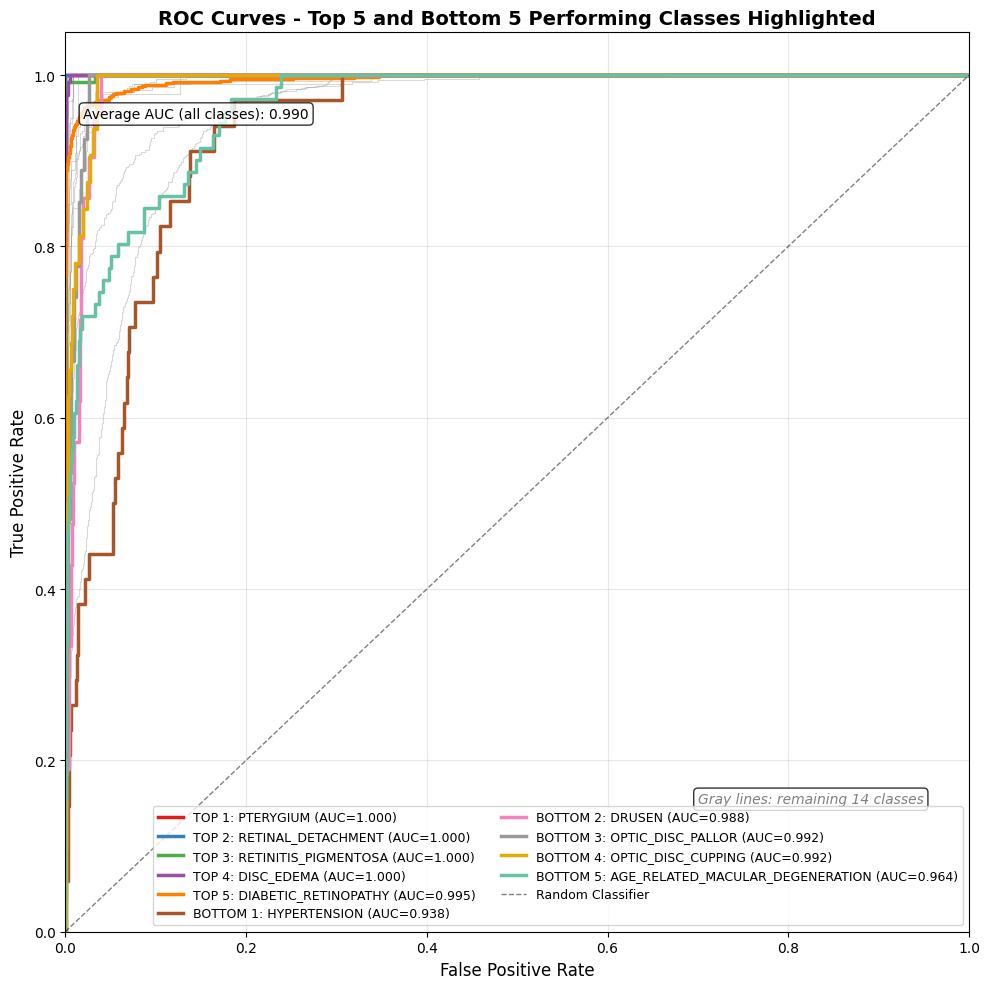


TOP 5 PERFORMING CLASSES (Highest F1 Score):
1. PTERYGIUM: F1=1.000, AUC=1.000
2. RETINAL_DETACHMENT: F1=0.992, AUC=1.000
3. RETINITIS_PIGMENTOSA: F1=0.977, AUC=1.000
4. DISC_EDEMA: F1=0.956, AUC=1.000
5. DIABETIC_RETINOPATHY: F1=0.944, AUC=0.995

BOTTOM 5 PERFORMING CLASSES (Lowest F1 Score):
1. HYPERTENSION: F1=0.000, AUC=0.938
2. DRUSEN: F1=0.167, AUC=0.988
3. OPTIC_DISC_PALLOR: F1=0.293, AUC=0.992
4. OPTIC_DISC_CUPPING: F1=0.326, AUC=0.992
5. AGE_RELATED_MACULAR_DEGENERATION: F1=0.585, AUC=0.964

Overall Statistics:
  Average F1 Score: 0.739
  Average AUC: 0.990
  Number of test samples: 3888


In [ ]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, f1_score
import os

from google.colab import drive
drive.mount('/content/drive')

# ============================================
# STEP 1: Load the extracted features
# ============================================
features_dir = "/content/drive/MyDrive/Deep Learning Project/Extracted Features/"

# Load test features and labels
shufflenet_data = np.load(os.path.join(features_dir, "shufflenet_features.npz"))
efficientnet_data = np.load(os.path.join(features_dir, "efficientnet_features.npz"))
resnet_data = np.load(os.path.join(features_dir, "resnet_features.npz"))

test_labels = shufflenet_data['test_labels']
shufflenet_test_features = shufflenet_data['test_features']
efficientnet_test_features = efficientnet_data['test_features']
resnet_test_features = resnet_data['test_features']

print(f"Loaded test features:")
print(f"  Labels shape: {test_labels.shape}")
print(f"  ShuffleNet: {shufflenet_test_features.shape}")
print(f"  EfficientNet: {efficientnet_test_features.shape}")
print(f"  ResNet: {resnet_test_features.shape}")

# ============================================
# STEP 2: Define model architectures
# ============================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class TransformerAttentionFusion(nn.Module):
    def __init__(self, dim_shuffle=1024, dim_eff=1280, dim_res=2048, embed_dim=512,
                 num_heads=8, num_transformer_layers=1, transformer_dropout=0.1):
        super().__init__()
        self.proj_shuffle = nn.Linear(dim_shuffle, embed_dim)
        self.proj_eff = nn.Linear(dim_eff, embed_dim)
        self.proj_res = nn.Linear(dim_res, embed_dim)
        self.norm_shuffle = nn.LayerNorm(embed_dim)
        self.norm_eff = nn.LayerNorm(embed_dim)
        self.norm_res = nn.LayerNorm(embed_dim)
        self.token_type_embed = nn.Parameter(torch.randn(1, 3, embed_dim))
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=num_heads, dim_feedforward=embed_dim * 2,
            dropout=transformer_dropout, activation="relu", batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_transformer_layers)
        self.attn_mlp = nn.Sequential(
            nn.Linear(embed_dim, 128), nn.ReLU(), nn.Linear(128, 1)
        )

    def forward(self, f_shuffle, f_eff, f_res):
        z_shuffle = self.norm_shuffle(self.proj_shuffle(f_shuffle))
        z_eff = self.norm_eff(self.proj_eff(f_eff))
        z_res = self.norm_res(self.proj_res(f_res))
        tokens = torch.stack([z_shuffle, z_eff, z_res], dim=1)
        tokens = tokens + self.token_type_embed
        tokens = self.transformer(tokens)
        scores = self.attn_mlp(tokens).squeeze(-1)
        weights = torch.softmax(scores, dim=1)
        fused = torch.sum(tokens * weights.unsqueeze(-1), dim=1)
        return fused, weights, tokens, scores

class PredictionBlock(nn.Module):
    def __init__(self, input_dim=512, hidden_dim=256, num_classes=24):
        super().__init__()
        self.net = nn.Sequential(
            nn.Dropout(0.1),
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.LayerNorm(hidden_dim),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, x):
        return self.net(x)

# ============================================
# STEP 3: Load trained model
# ============================================
save_path = "/content/drive/MyDrive/Deep Learning Project/Extracted Features/best_transformer_prediction_block.pth"

fusion_model = TransformerAttentionFusion().to(device)
prediction_block = PredictionBlock().to(device)

checkpoint = torch.load(save_path, map_location=device)
fusion_model.load_state_dict(checkpoint["fusion_model_state_dict"])
prediction_block.load_state_dict(checkpoint["prediction_block_state_dict"])
fusion_model.eval()
prediction_block.eval()

print(f"\nLoaded model from epoch: {checkpoint['epoch']}")

# ============================================
# STEP 4: Get predictions
# ============================================
LABEL_COLS = [
    'CENTRAL_SEROUS_RETINOPATHY', 'DIABETIC_RETINOPATHY', 'GLAUCOMA', 'NORMAL',
    'MACULAR_SCAR', 'MYOPIA', 'PTERYGIUM', 'RETINAL_DETACHMENT', 'RETINITIS_PIGMENTOSA',
    'HYPERTENSION', 'CATARACT', 'AGE_RELATED_MACULAR_DEGENERATION', 'DISC_EDEMA',
    'MEDIA_HAZE', 'OPTIC_DISC_CUPPING', 'TESSELLATION', 'DRUSEN',
    'BRANCH_RETINAL_VEIN_OCCLUSION', 'OPTIC_DISC_PALLOR', 'CENTRAL_RETINAL_VEIN_OCCLUSION',
    'CHOROIDAL_NEOVASCULARIZATION', 'RETINITIS', 'LASER_SCARS', 'ARTERIOSCLEROTIC_RETINOPATHY'
]

# Convert to tensors
shufflenet_test_tensor = torch.tensor(shufflenet_test_features, dtype=torch.float32).to(device)
efficientnet_test_tensor = torch.tensor(efficientnet_test_features, dtype=torch.float32).to(device)
resnet_test_tensor = torch.tensor(resnet_test_features, dtype=torch.float32).to(device)

# Get predictions
all_probs = []
batch_size = 32

with torch.no_grad():
    for i in range(0, len(shufflenet_test_tensor), batch_size):
        batch_shuffle = shufflenet_test_tensor[i:i+batch_size]
        batch_eff = efficientnet_test_tensor[i:i+batch_size]
        batch_res = resnet_test_tensor[i:i+batch_size]

        fused, _, _, _ = fusion_model(batch_shuffle, batch_eff, batch_res)
        logits = prediction_block(fused)
        probs = torch.sigmoid(logits)
        all_probs.append(probs.cpu().numpy())

all_probs = np.vstack(all_probs)
print(f"Predictions shape: {all_probs.shape}")

# ============================================
# STEP 5: Create AUC-ROC plot
# ============================================
# Calculate per-class F1 scores
per_class_f1 = f1_score(test_labels, (all_probs >= 0.5).astype(int), average=None, zero_division=0)

# Get top 5 and bottom 5 indices
top5_indices = np.argsort(per_class_f1)[::-1][:5]
bottom5_indices = np.argsort(per_class_f1)[:5]

# Colors
top_colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00']
bottom_colors = ['#a65628', '#f781bf', '#999999', '#e6ab02', '#66c2a5']

# Create plot
plt.figure(figsize=(10, 10))

# Plot all non-highlighted classes in gray
for i in range(len(LABEL_COLS)):
    if i in top5_indices or i in bottom5_indices:
        continue
    fpr, tpr, _ = roc_curve(test_labels[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color='gray', alpha=0.3, linewidth=0.8)

# Plot top 5 classes
for j, idx in enumerate(top5_indices):
    fpr, tpr, _ = roc_curve(test_labels[:, idx], all_probs[:, idx])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=top_colors[j], linewidth=2.5,
             label=f'TOP {j+1}: {LABEL_COLS[idx]} (AUC={roc_auc:.3f})')

# Plot bottom 5 classes
for j, idx in enumerate(bottom5_indices):
    fpr, tpr, _ = roc_curve(test_labels[:, idx], all_probs[:, idx])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=bottom_colors[j], linewidth=2.5,
             label=f'BOTTOM {j+1}: {LABEL_COLS[idx]} (AUC={roc_auc:.3f})')

# Diagonal line
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Random Classifier')

# Customize plot
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - Top 5 and Bottom 5 Performing Classes Highlighted', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=9, ncol=2)
plt.grid(True, alpha=0.3)

# Add annotation
remaining = len(LABEL_COLS) - 10
plt.text(0.7, 0.15, f'Gray lines: remaining {remaining} classes',
         fontsize=10, color='gray', style='italic',
         bbox=dict(boxstyle="round", facecolor='white', alpha=0.8))

# Calculate and display average AUC
all_aucs = []
for i in range(len(LABEL_COLS)):
    fpr, tpr, _ = roc_curve(test_labels[:, i], all_probs[:, i])
    all_aucs.append(auc(fpr, tpr))
avg_auc = np.mean(all_aucs)

plt.text(0.02, 0.95, f'Average AUC (all classes): {avg_auc:.3f}',
         fontsize=10, bbox=dict(boxstyle="round", facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

# ============================================
# Print summary statistics
# ============================================
print("\n" + "="*70)
print("TOP 5 PERFORMING CLASSES (Highest F1 Score):")
print("="*70)
for j, idx in enumerate(top5_indices):
    fpr, tpr, _ = roc_curve(test_labels[:, idx], all_probs[:, idx])
    roc_auc = auc(fpr, tpr)
    print(f"{j+1}. {LABEL_COLS[idx]}: F1={per_class_f1[idx]:.3f}, AUC={roc_auc:.3f}")

print("\n" + "="*70)
print("BOTTOM 5 PERFORMING CLASSES (Lowest F1 Score):")
print("="*70)
for j, idx in enumerate(bottom5_indices):
    fpr, tpr, _ = roc_curve(test_labels[:, idx], all_probs[:, idx])
    roc_auc = auc(fpr, tpr)
    print(f"{j+1}. {LABEL_COLS[idx]}: F1={per_class_f1[idx]:.3f}, AUC={roc_auc:.3f}")

print(f"\n{'='*70}")
print(f"Overall Statistics:")
print(f"  Average F1 Score: {np.mean(per_class_f1):.3f}")
print(f"  Average AUC: {avg_auc:.3f}")
print(f"  Number of test samples: {len(test_labels)}")